# FIAP TECH CHALLENGE 1 - GRUPO SSP

## 4
. COMPARAÇÃO DE MODELOS

Neste notebook vamos treinar, rodar e comparar 3 modelos preditivos: Regressão Logística, KNN e Random Forest. Escolhemos a regressão logística por sua relativa simplicidade e tempo de existência. Já os modelos KNN e RF são funcionam bem com dados categóricos/binários (segundo nossas pesquisas), que representam a grande maioria das colunas do nosso dataset.

### 4.1. Preparação e Análise dos Dados

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

BASE_PATH = Path.cwd().resolve().parent.parent
print(f"Base path: {BASE_PATH.absolute()}")

Base path: /Users/matias/Projetos/fiap/tech-challenge-1


In [2]:
# Carregar dados pré-processados
df = pd.read_parquet(BASE_PATH / "data" / "processed" / "df_preprocessed.parquet")
print(f"Shape do dataset: {df.shape}")

# Preparar features e target
X = df.drop(columns=['OUT_VEZES'])
y = df['OUT_VEZES']

# Encoding categórico
label_encoders = {}
X_encoded = X.copy()

for col in X_encoded.columns:
    col_data = X_encoded[col].astype(str).replace('nan', np.nan)
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(col_data.fillna(col_data.mode()[0] if len(col_data.mode()) > 0 else '0'))
    label_encoders[col] = le

print(f"\nFeatures preparadas: {X_encoded.shape}")
print(f"Target: {y.value_counts().to_dict()}")

Shape do dataset: (57022, 38)

Features preparadas: (57022, 37)
Target: {1.0: 30277, 0.0: 26745}


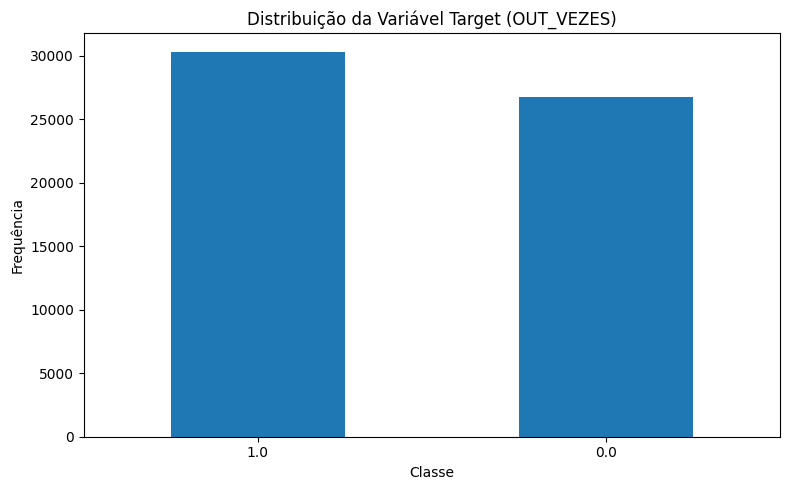

Treino: 39915 amostras
Teste: 17107 amostras


In [3]:
# Análise da variável target
plt.figure(figsize=(8, 5))
y.value_counts().plot(kind='bar')
plt.title('Distribuição da Variável Target (OUT_VEZES)')
plt.xlabel('Classe')
plt.ylabel('Frequência')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, 
    test_size=0.3, 
    random_state=42, 
    stratify=y
)

# Normalização
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Treino: {X_train_scaled.shape[0]} amostras")
print(f"Teste: {X_test_scaled.shape[0]} amostras")

### 4.2. Otimização e Treinamento dos Modelos

Nos três modelos nós percebemos que há múltiplos parâmetros que podem influenciar nas métricas dos resultados então criamos um iteração para encontrar algo próximo de um conjunto de parâmetros otimizados para o experimento

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, cross_val_score

models = {}
best_params = {}

In [5]:
# Regressão Logística
print("Otimizando Regressão Logística...")
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'l1_ratio': [0, 1],  # l1_ratio=0 for l2, l1_ratio=1 for l1
    'solver': ['saga'],
    'class_weight': ['balanced', None]
}

lr_base = LogisticRegression(max_iter=1000, random_state=42)
lr_search = RandomizedSearchCV(
    lr_base, param_grid_lr, n_iter=10, cv=5, 
    scoring='roc_auc', n_jobs=-1, random_state=42
)
lr_search.fit(X_train_scaled, y_train)
best_params['LogisticRegression'] = lr_search.best_params_
models['LogisticRegression'] = lr_search.best_estimator_
l1_ratio = lr_search.best_params_.get('l1_ratio', None)
penalty_str = 'l1' if l1_ratio == 1 else 'l2' if l1_ratio == 0 else 'none'
print(f"Melhor C: {lr_search.best_params_['C']}, L1 Ratio: {l1_ratio} (equivale a penalty={penalty_str})")
print(f"Melhores parâmetros: {lr_search.best_params_}")

Otimizando Regressão Logística...
Melhor C: 0.01, L1 Ratio: 0 (equivale a penalty=l2)
Melhores parâmetros: {'solver': 'saga', 'l1_ratio': 0, 'class_weight': 'balanced', 'C': 0.01}


In [6]:
# KNN - Otimização de k
print("Otimizando KNN...")
k_values = range(1, 31, 2)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='roc_auc')
    cv_scores.append(scores.mean())

best_k = k_values[np.argmax(cv_scores)]
best_params['KNN'] = {'n_neighbors': best_k}
models['KNN'] = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
models['KNN'].fit(X_train_scaled, y_train)
print(f"Melhor k: {best_k}")

Otimizando KNN...
Melhor k: 29


In [7]:
# Random Forest
print("Otimizando Random Forest...")
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', None]
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_search = RandomizedSearchCV(
    rf_base, param_grid_rf, n_iter=20, cv=5,
    scoring='roc_auc', n_jobs=-1, random_state=42
)
rf_search.fit(X_train_scaled, y_train)
best_params['RandomForest'] = rf_search.best_params_
models['RandomForest'] = rf_search.best_estimator_
print(f"Melhores parâmetros: {rf_search.best_params_}")

Otimizando Random Forest...
Melhores parâmetros: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 20, 'class_weight': None}


### 4.3. Avaliação Comparativa

In [8]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

results = {}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None
    
    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'f1': f1_score(y_test, y_pred, average='weighted', zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }

# Tabela comparativa
comparison_df = pd.DataFrame({
    'Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'Precision': [results[m]['precision'] for m in results.keys()],
    'Recall': [results[m]['recall'] for m in results.keys()],
    'F1-Score': [results[m]['f1'] for m in results.keys()],
    'ROC-AUC': [results[m]['roc_auc'] if results[m]['roc_auc'] else np.nan for m in results.keys()]
}, index=results.keys())

print("Comparação de Métricas:")
print(comparison_df.round(4))

Comparação de Métricas:
                    Accuracy  Precision  Recall  F1-Score  ROC-AUC
LogisticRegression    0.7006     0.7003  0.7006    0.6995   0.7600
KNN                   0.7015     0.7025  0.7015    0.6991   0.7558
RandomForest          0.7187     0.7222  0.7187    0.7151   0.7850


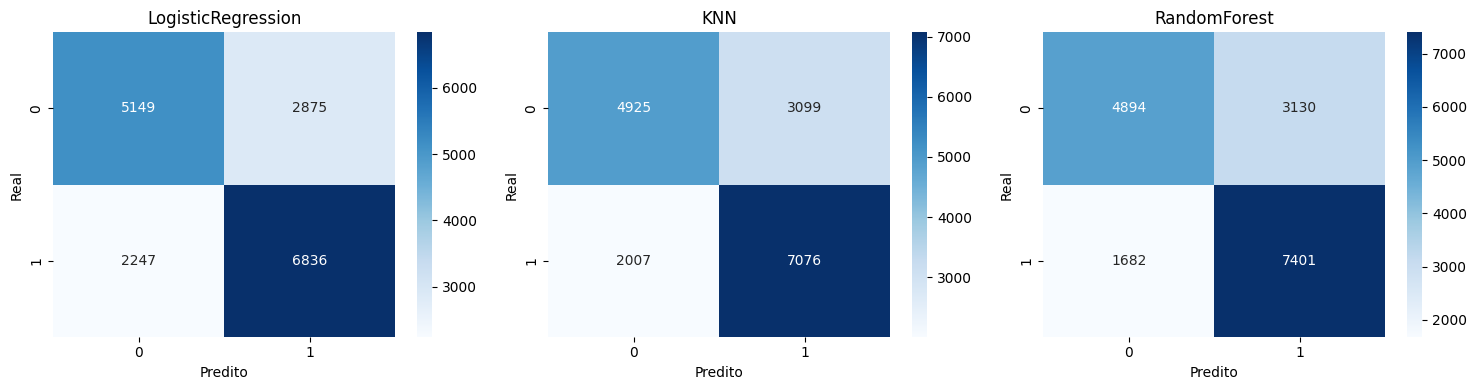

In [9]:
# Matrizes de confusão
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (name, result) in enumerate(results.items()):
    cm = confusion_matrix(y_test, result['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f'{name}')
    axes[idx].set_ylabel('Real')
    axes[idx].set_xlabel('Predito')

plt.tight_layout()
plt.show()

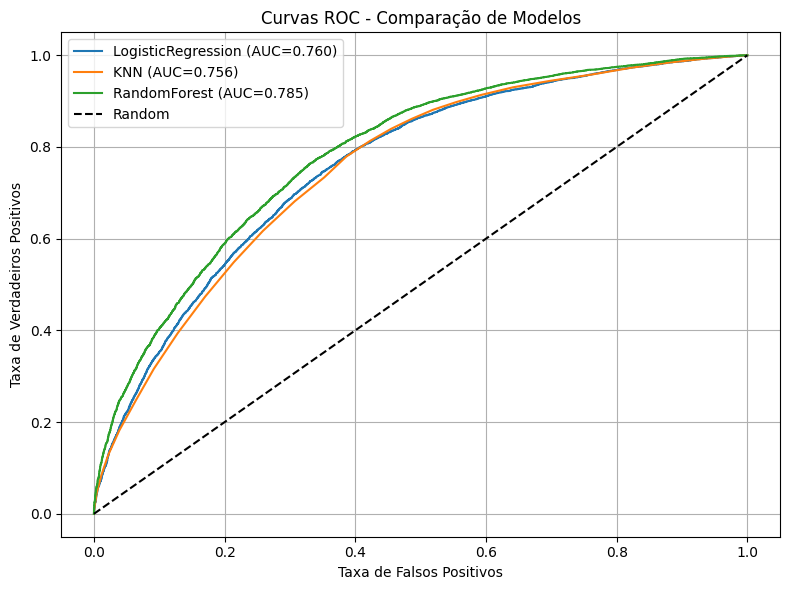

In [10]:
# Curvas ROC
plt.figure(figsize=(8, 6))

for name, result in results.items():
    if result['y_pred_proba'] is not None:
        fpr, tpr, _ = roc_curve(y_test, result['y_pred_proba'])
        plt.plot(fpr, tpr, label=f"{name} (AUC={result['roc_auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curvas ROC - Comparação de Modelos')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

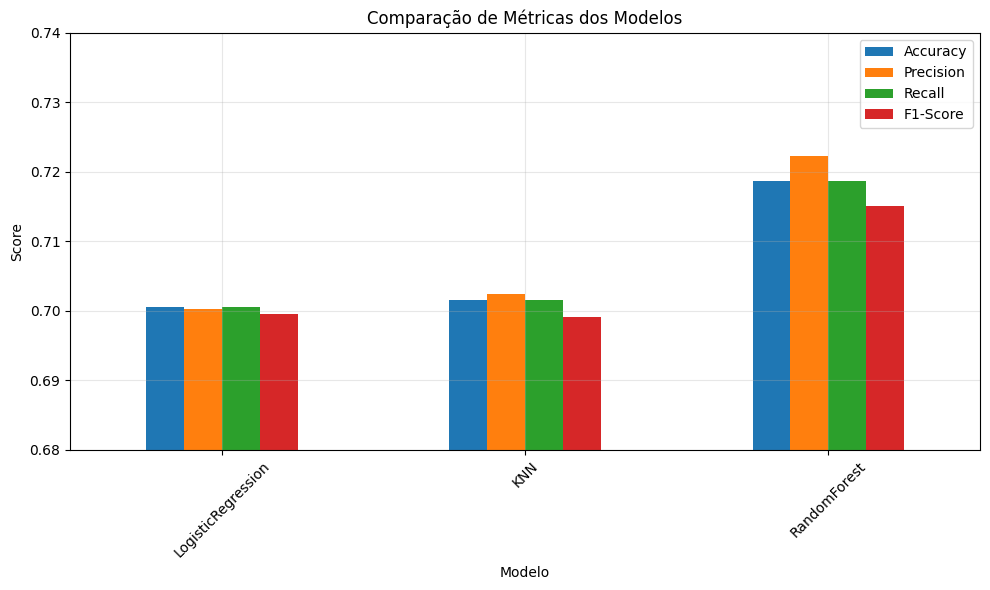

In [11]:
# Gráfico de barras comparativo
comparison_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(kind='bar', figsize=(10, 6))
plt.title('Comparação de Métricas dos Modelos')
plt.ylabel('Score')
plt.xlabel('Modelo')
# focando o score entre 0.5 e 0.8
plt.ylim(0.68, 0.74)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()